#Physical Activity, Diet, and Sleep as Correlates of Self-Reported Health: Evidence from NHANES 2013–2014
Data source: U.S. National Health and Nutrition Examination Survey (NHANES), 2013–2014 cycle (demographic, dietary, examination, laboratory, medications, and questionnaire files), linked on the unique respondent identifier SEQN.

##1. Background and Research Questions
Physical activity, dietary intake, and sleep are three of the most consistently studied modifiable behaviors in population health research, yet most single-behavior studies do not examine how all three move together across the lifespan or jointly relate to how people perceive their own health. Self-reported health (SRH) is a well-validated summary measure that predicts mortality and morbidity independent of clinical markers.

Research questions

How do physical activity, dietary quality, and sleep duration differ across adult age groups (18–29, 30–49, 50–64, 65+)?
Are these three behaviors independently associated with self-reported health, after adjusting for socio-demographic and clinical covariates?
Does the association between each behavior and self-reported health vary by age group (effect modification)?
Hypotheses

H1: Physical activity and sleep sufficiency decline with age, while dietary quality (nutrient density) improves with age.
H2: Higher physical activity, better diet quality, and adequate sleep duration are each independently associated with higher odds of good/very good/excellent self-reported health.
H3: The protective association of physical activity with self-reported health is attenuated in older age groups (i.e., a behavior × age interaction).


In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats

pd.set_option('display.max_columns', 60)
sns.set_theme(style='whitegrid', font_scale=1.0)
palette = sns.color_palette('viridis', 4)
np.random.seed(42)

## Data Loading

All six NHANES 2013–2014 component files are loaded. `SEQN` is the unique respondent ID that links every file. `demographic` and `questionnaire` include every sampled person (interview-level, N=10,175); `examination`, `diet`, and `labs` are restricted to respondents who additionally attended the Mobile Examination Center (N=9,813). `medications` is a long file (one row per medication reported, N=20,194) and must be aggregated to one row per person before merging.

In [3]:
import pandas as pd
demo = pd.read_csv(r"C:\Users\user\Desktop\HYGEIA\demographic.csv")
exam = pd.read_csv(r"C:\Users\user\Desktop\HYGEIA\examination.csv")
diet = pd.read_csv(r"C:\Users\user\Desktop\HYGEIA\diet.csv")
labs = pd.read_csv(r"C:\Users\user\Desktop\HYGEIA\labs.csv")
ques = pd.read_csv(r"C:\Users\user\Desktop\HYGEIA\questionnaire.csv")
meds = pd.read_csv(r"C:\Users\user\Desktop\HYGEIA\medications.csv", encoding="latin1")

print(f"{'File':<14}{'Rows':>8}{'Cols':>8}")

for name, d in [
    ('demographic', demo),
    ('examination', exam),
    ('diet', diet),
    ('labs', labs),
    ('questionnaire', ques),
    ('medications', meds)
]:
    print(f"{name:<14}{d.shape[0]:>8}{d.shape[1]:>8}")

File              Rows    Cols
demographic      10175      47
examination       9813     224
diet              9813     168
labs              9813     424
questionnaire    10175     953
medications      20194      13


In [4]:
# Aggregate medications to one row per person
meds_agg = meds.groupby('SEQN').agg(MED_COUNT=('RXDDRUG','count')).reset_index()
meds_agg['MED_ANYUSE'] = (meds_agg['MED_COUNT']>0).astype(int)
meds_agg.head()

,SEQN,MED_COUNT,MED_ANYUSE
0,73557,2,1
1,73558,4,1
2,73559,5,1
3,73560,0,0
4,73561,4,1


## Variable Selection
Guided by the research questions, we retain: demographics/design variables (age, sex, race/ethnicity, education, poverty-income ratio, survey weights, PSU/strata), body measures and blood pressure, day-1 dietary recall totals, a compact clinical lab panel, the physical activity (PAQ) and sleep (SLQ/SLD) questionnaire batteries, self-reported health (HSD010), and chronic-disease/medication indicators used as covariates.

In [5]:
demo_sel = demo[['SEQN','RIDAGEYR','RIAGENDR','RIDRETH3','DMDEDUC2','DMDMARTL',
                  'INDFMPIR','WTINT2YR','WTMEC2YR','SDMVPSU','SDMVSTRA']].copy()

exam_sel = exam[['SEQN','BMXBMI','BMXWT','BMXHT','BMXWAIST','BPXSY1','BPXDI1']].copy()

diet_sel = diet[['SEQN','WTDRD1','DR1TKCAL','DR1TPROT','DR1TCARB','DR1TSUGR','DR1TFIBE',
                  'DR1TTFAT','DR1TSFAT','DR1TSODI','DR1TPOTA','DR1TCALC','DR1TVC','DR1TALCO']].copy()

labs_sel = labs[['SEQN','LBXGH','LBXTC','LBDLDL','LBXTR','LBXSCR']].copy()

ques_sel = ques[['SEQN','PAQ605','PAQ610','PAD615','PAQ620','PAQ625','PAD630',
                  'PAQ635','PAQ640','PAD645','PAQ650','PAQ655','PAD660',
                  'PAQ665','PAQ670','PAD675','PAD680',
                  'SLD010H','SLQ050','SLQ060',
                  'HSD010','DIQ010','BPQ020','SMQ020','MCQ160A','MCQ160B','MCQ160C',
                  'MCQ160F','MCQ220']].copy()
print('Selected variable counts:', demo_sel.shape[1], exam_sel.shape[1], diet_sel.shape[1],
      labs_sel.shape[1], ques_sel.shape[1])

Selected variable counts: 11 7 14 6 29


## Recoding NHANES Missing/Special Codes

NHANES uses reserved numeric codes for item non-response: `7`/`77`/`7777` = Refused, and `9`/`99`/`9999` = Don't know, depending on field width. These are recoded to `NaN` so they are not mistaken for valid values (e.g., "9 days/week" or "99 minutes").

In [6]:
def recode_missing(df, cols, bad_vals):
    for c in cols:
        df[c] = df[c].replace(bad_vals, np.nan)
    return df

yesno_79   = [7,9]
days_7799  = [77,99]
min_777799 = [7777,9999]

ques_sel = recode_missing(ques_sel, ['PAQ605','PAQ620','PAQ635','PAQ650','PAQ665',
                                      'SLQ050','SLQ060','DIQ010','BPQ020','SMQ020',
                                      'MCQ160A','MCQ160B','MCQ160C','MCQ160F','MCQ220'], yesno_79)
ques_sel = recode_missing(ques_sel, ['PAQ610','PAQ625','PAQ640','PAQ655','PAQ670'], days_7799)
ques_sel = recode_missing(ques_sel, ['PAD615','PAD630','PAD645','PAD660','PAD675','PAD680'], min_777799)
ques_sel = recode_missing(ques_sel, ['SLD010H'], [77,99])
ques_sel = recode_missing(ques_sel, ['HSD010'], [7,9])
# DIQ010 code 3 = "borderline" diabetes; this is a genuine response category, not recoded.
ques_sel[['PAQ605','SLD010H','HSD010']].describe()

,PAQ605,SLD010H,HSD010
count,7147.000000,6454.000000,6466.000000
mean,1.836015,6.950573,2.767089
std,0.370288,1.428129,0.967950
min,1.000000,2.000000,1.000000
25%,2.000000,6.000000,2.000000
50%,2.000000,7.000000,3.000000
75%,2.000000,8.000000,3.000000
max,2.000000,12.000000,5.000000


## Derived Variable: Physical Activity (MET-minutes/week)

Following the WHO Global Physical Activity Questionnaire (GPAQ) analysis convention that NHANES's PAQ battery mirrors, total physical activity volume is computed as:

$$
\text{MET-min/wk} = \sum(\text{days/week} \times \text{minutes/day} \times \text{MET value})
$$

using standard MET values of **8.0** for vigorous activity and **4.0** for moderate activity, summed across the work and recreational domains.

Respondents who answered **"No"** to doing a given activity type (skip pattern) contribute `0` MET-minutes for that component rather than a missing value.

Individuals are then classified per WHO 2020 guideline thresholds:

- **Low/Inactive:** <600 MET-min/wk
- **Moderate:** 600–<3000 MET-min/wk
- **High:** ≥3000 MET-min/wk

In [8]:
def met_component(freq_days, minutes, met):
    f = freq_days.where(freq_days.between(0,7))
    m = minutes.where(minutes.between(0,960))
    return f * m * met

ques_sel['MET_VIG_WORK'] = met_component(ques_sel['PAQ610'], ques_sel['PAD615'], 8.0)
ques_sel['MET_MOD_WORK'] = met_component(ques_sel['PAQ625'], ques_sel['PAD630'], 4.0)
ques_sel['MET_VIG_REC']  = met_component(ques_sel['PAQ640'], ques_sel['PAD645'], 8.0)
ques_sel['MET_MOD_REC']  = met_component(ques_sel['PAQ655'], ques_sel['PAD660'], 4.0)

ques_sel.loc[ques_sel['PAQ605']==2, 'MET_VIG_WORK'] = 0
ques_sel.loc[ques_sel['PAQ620']==2, 'MET_MOD_WORK'] = 0
ques_sel.loc[ques_sel['PAQ635']==2, 'MET_VIG_REC']  = 0
ques_sel.loc[ques_sel['PAQ650']==2, 'MET_MOD_REC']  = 0

met_cols = ['MET_VIG_WORK','MET_MOD_WORK','MET_VIG_REC','MET_MOD_REC']
ques_sel['PA_TOTAL_METMIN_WK'] = ques_sel[met_cols].sum(axis=1, min_count=1)

def pa_cat(x):
    if pd.isna(x): return np.nan
    if x < 600: return 'Low (Inactive)'
    elif x < 3000: return 'Moderate'
    else: return 'High'
ques_sel['PA_CATEGORY'] = pd.Categorical(ques_sel['PA_TOTAL_METMIN_WK'].apply(pa_cat),
                             categories=['Low (Inactive)','Moderate','High'], ordered=True)
ques_sel['SEDENTARY_HRS_DAY'] = ques_sel['PAD680'] / 60.0
ques_sel['PA_CATEGORY'].value_counts(dropna=False)

PA_CATEGORY
Low (Inactive)    3385
NaN               3027
Moderate          1983
High              1780
Name: count, dtype: int64

## Derived Variables: Sleep and Self-Reported Health

- **Sleep:** `SLD010H` (usual hours of sleep on weekdays/workdays) is categorized as **Short** (<6h), **Recommended** (6–9h, per AASM/Sleep Foundation adult guidance), or **Long** (>9h).

- **Self-reported health:** `HSD010` (1=Excellent...5=Poor) is reverse-coded to an ordinal scale where higher = better, and a binary version is created (**Excellent/Very good/Good = 1** vs. **Fair/Poor = 0**), consistent with common SRH dichotomization in the epidemiologic literature.

- **Chronic disease burden:** A simple count across arthritis, congestive heart failure, coronary heart disease, stroke, and cancer diagnoses, plus separate diabetes, hypertension, and smoking flags, is built for use as covariates.

In [9]:
def sleep_cat(h):
    if pd.isna(h): return np.nan
    if h < 6: return 'Short (<6h)'
    elif h <= 9: return 'Recommended (6-9h)'
    else: return 'Long (>9h)'
ques_sel['SLEEP_CATEGORY'] = pd.Categorical(ques_sel['SLD010H'].apply(sleep_cat),
                                categories=['Short (<6h)','Recommended (6-9h)','Long (>9h)'], ordered=True)
ques_sel['TROUBLE_SLEEPING'] = ques_sel['SLQ050'].map({1:1,2:0})

ques_sel['SRH_ORDINAL'] = 6 - ques_sel['HSD010']
srh_labels = {5:'Excellent',4:'Very good',3:'Good',2:'Fair',1:'Poor'}
ques_sel['SRH_LABEL'] = pd.Categorical(ques_sel['SRH_ORDINAL'].map(srh_labels),
                            categories=['Poor','Fair','Good','Very good','Excellent'], ordered=True)
ques_sel['SRH_GOOD_BINARY'] = (ques_sel['HSD010']<=3).astype(float)
ques_sel.loc[ques_sel['HSD010'].isna(),'SRH_GOOD_BINARY'] = np.nan

chronic_flags = ['MCQ160A','MCQ160B','MCQ160C','MCQ160F','MCQ220']
for c in chronic_flags:
    ques_sel[c+'_f'] = (ques_sel[c]==1).astype(float)
ques_sel['DIABETES'] = ques_sel['DIQ010'].map({1:1,2:0,3:1})
ques_sel['HYPERTENSION'] = ques_sel['BPQ020'].map({1:1,2:0})
ques_sel['CURRENT_EVER_SMOKER'] = ques_sel['SMQ020'].map({1:1,2:0})
ques_sel['CHRONIC_DISEASE_COUNT'] = ques_sel[[c+'_f' for c in chronic_flags]].sum(axis=1, min_count=1)

print(ques_sel['SLEEP_CATEGORY'].value_counts(dropna=False))
print(ques_sel['SRH_LABEL'].value_counts(dropna=False))

SLEEP_CATEGORY
Recommended (6-9h)    5370
NaN                   3721
Short (<6h)            860
Long (>9h)             224
Name: count, dtype: int64
SRH_LABEL
NaN          3709
Good         2605
Very good    1826
Fair         1186
Excellent     641
Poor          208
Name: count, dtype: int64


## Derived Variable: Nutrient-Based Diet Quality Score (DQS)

**Important scope note:** The diet file provides *nutrient totals* from a single 24-hour recall, not food-group serving counts. A full Healthy Eating Index-2015 cannot be computed from this file. Instead, we construct a transparent, six-component **Diet Quality Score (0–100)** using the same "density per 1000 kcal, capped" logic that HEI-style indices use for adequacy nutrients (fiber, potassium, calcium — higher is better, capped at a target) and moderation nutrients (saturated fat, added sugar, sodium as % of energy — lower is better, floored at a target).

Each of the six components is scored **0–10** and summed to a **0–100** scale.

This is reported explicitly as a **study-specific index**, not a validated external instrument, which is an appropriate methodological disclosure for a research write-up.

In [10]:
d = diet_sel.copy()
d = d[d['DR1TKCAL']>0]
kcal = d['DR1TKCAL']

def score_adequacy(x_per_1000kcal, good_at):
    return (10 * (x_per_1000kcal / good_at)).clip(0,10)

def score_moderation(x_pct_kcal, bad_at, ok_at):
    return (10 * (bad_at - x_pct_kcal) / (bad_at - ok_at)).clip(0,10)

d['SC_FIBER']      = score_adequacy(d['DR1TFIBE']/kcal*1000, good_at=14)
d['SC_POTASSIUM']  = score_adequacy(d['DR1TPOTA']/kcal*1000, good_at=1590)
d['SC_CALCIUM']    = score_adequacy(d['DR1TCALC']/kcal*1000, good_at=550)
d['SC_SATFAT']     = score_moderation(d['DR1TSFAT']*9/kcal*100, bad_at=16, ok_at=8)
d['SC_ADDSUGAR']   = score_moderation(d['DR1TSUGR']*4/kcal*100, bad_at=26, ok_at=10)
d['SC_SODIUM']     = score_moderation(d['DR1TSODI']/kcal*1000, bad_at=2000, ok_at=1100)

dqs_cols = ['SC_FIBER','SC_POTASSIUM','SC_CALCIUM','SC_SATFAT','SC_ADDSUGAR','SC_SODIUM']
d['DIET_QUALITY_SCORE'] = d[dqs_cols].sum(axis=1, min_count=len(dqs_cols)) / (10*len(dqs_cols)) * 100

def dqs_cat(x):
    if pd.isna(x): return np.nan
    if x < 40: return 'Low'
    elif x < 65: return 'Moderate'
    else: return 'High'
d['DIET_QUALITY_CAT'] = pd.Categorical(d['DIET_QUALITY_SCORE'].apply(dqs_cat),
                            categories=['Low','Moderate','High'], ordered=True)

diet_final = d[['SEQN','WTDRD1','DR1TKCAL','DR1TPROT','DR1TCARB','DR1TSUGR','DR1TFIBE',
                 'DR1TTFAT','DR1TSFAT','DR1TSODI','DR1TPOTA','DR1TCALC','DR1TVC','DR1TALCO',
                 'DIET_QUALITY_SCORE','DIET_QUALITY_CAT']]
diet_final['DIET_QUALITY_SCORE'].describe()

count    8531.000000
mean       57.851852
std        11.403826
min        20.201124
25%        49.498260
50%        57.236966
75%        65.793381
max       100.000000
Name: DIET_QUALITY_SCORE, dtype: float64

## Merging All Components and Defining the Analytic Sample

All files are merged on `SEQN`. Because the physical activity, sleep, and self-reported health questions follow an **adult-only skip pattern** in NHANES, the analytic sample is restricted to respondents aged **18 years and older**.

Standard NHANES adult age bands are used:

- **18–29 years**
- **30–49 years**
- **50–64 years**
- **65+ years**

In [11]:
df = demo_sel.merge(exam_sel, on='SEQN', how='left') \
             .merge(diet_final, on='SEQN', how='left') \
             .merge(labs_sel, on='SEQN', how='left') \
             .merge(ques_sel, on='SEQN', how='left') \
             .merge(meds_agg, on='SEQN', how='left')
df['MED_COUNT'] = df['MED_COUNT'].fillna(0)
df['MED_ANYUSE'] = df['MED_ANYUSE'].fillna(0)
print('Full merged N =', df.shape)

df = df[df['RIDAGEYR']>=18].copy()
bins = [18,30,50,65,150]
labels = ['18-29','30-49','50-64','65+']
df['AGE_GROUP'] = pd.cut(df['RIDAGEYR'], bins=bins, labels=labels, right=False)

df['SEX'] = df['RIAGENDR'].map({1:'Male',2:'Female'})
race_map = {1:'Mexican American',2:'Other Hispanic',3:'Non-Hispanic White',
            4:'Non-Hispanic Black',6:'Non-Hispanic Asian',7:'Other/Multi'}
df['RACE_ETH'] = df['RIDRETH3'].map(race_map)
educ_map = {1:'<9th grade',2:'9-11th grade',3:'HS grad/GED',4:'Some college/AA',5:'College grad+'}
df['EDUCATION'] = df['DMDEDUC2'].map(educ_map)

print('Adults 18+ analytic frame N =', df.shape[0])
df['AGE_GROUP'].value_counts().sort_index()

Full merged N = (10175, 88)
Adults 18+ analytic frame N = 6113


AGE_GROUP
18-29    1300
30-49    2033
50-64    1474
65+      1306
Name: count, dtype: int64

## Missing Data Assessment

Missingness is assessed on the full set of analytic variables before deciding on a complete-case approach. Non-response is highest for diet (~12%, one common recall non-response rate) and self-reported health (~11%, largely non-response to the health-status interview module).

Physical activity is essentially complete (0%) because **"No"** answers to the activity screening questions are valid zero-activity responses rather than missing data.

In [12]:
key_vars = ['AGE_GROUP','SEX','PA_TOTAL_METMIN_WK','PA_CATEGORY','SLD010H','SLEEP_CATEGORY',
            'DIET_QUALITY_SCORE','SRH_LABEL','SRH_GOOD_BINARY','BMXBMI','INDFMPIR',
            'EDUCATION','WTMEC2YR','WTDRD1']
miss = df[key_vars].isna().mean().sort_values(ascending=False)*100
print(miss.round(1))

complete = df.dropna(subset=['AGE_GROUP','PA_CATEGORY','SLEEP_CATEGORY','DIET_QUALITY_SCORE',
                              'SRH_LABEL','BMXBMI','WTMEC2YR','SDMVPSU','INDFMPIR','EDUCATION'])
print('\nComplete-case analytic N =', complete.shape[0], f"({complete.shape[0]/df.shape[0]*100:.1f}% of adult frame)")

WTDRD1                12.4
DIET_QUALITY_SCORE    12.4
SRH_LABEL             11.0
SRH_GOOD_BINARY       11.0
INDFMPIR               7.9
EDUCATION              5.7
BMXBMI                 4.4
SLD010H                0.1
SLEEP_CATEGORY         0.1
SEX                    0.0
PA_TOTAL_METMIN_WK     0.0
PA_CATEGORY            0.0
AGE_GROUP              0.0
WTMEC2YR               0.0
dtype: float64

Complete-case analytic N = 4459 (72.9% of adult frame)


## Weighted Descriptive Statistics (Table 1)

NHANES uses a complex, multistage probability sample; unweighted statistics do not represent the U.S. population.

We apply the **MEC examination weight (`WTMEC2YR`)** — the appropriate weight for this analysis because the outcome variable and BMI covariate require MEC attendance, and it is the least-restrictive weight common to every file merged here (diet, labs, exam, questionnaire).

Where a biomarker analysis is restricted further (e.g., fasting-only labs), a fasting-subsample weight would be required instead; none of our final analytic variables have that restriction.

In [13]:
def weighted_mean_sd(x, w):
    x = np.asarray(x, dtype=float); w = np.asarray(w, dtype=float)
    mask = ~np.isnan(x) & ~np.isnan(w)
    x, w = x[mask], w[mask]
    m = np.average(x, weights=w)
    var = np.average((x-m)**2, weights=w)
    return m, np.sqrt(var)

table1 = {}
for ag in labels:
    sub = complete[complete['AGE_GROUP']==ag]
    w = sub['WTMEC2YR']
    row = {}
    row['N (unweighted)'] = len(sub)
    m,s = weighted_mean_sd(sub['PA_TOTAL_METMIN_WK'], w); row['PA, MET-min/wk (mean, SD)'] = f'{m:.0f} ({s:.0f})'
    m,s = weighted_mean_sd(sub['SLD010H'], w);           row['Sleep, hours (mean, SD)'] = f'{m:.2f} ({s:.2f})'
    m,s = weighted_mean_sd(sub['DIET_QUALITY_SCORE'], w);row['Diet quality score, 0-100 (mean, SD)'] = f'{m:.1f} ({s:.1f})'
    m,s = weighted_mean_sd(sub['BMXBMI'], w);             row['BMI, kg/m2 (mean, SD)'] = f'{m:.1f} ({s:.1f})'
    m,s = weighted_mean_sd(sub['SRH_GOOD_BINARY']*100, w);row['% Good+ self-rated health'] = f'{m:.1f}%'
    table1[ag] = row

table1_df = pd.DataFrame(table1)
table1_df

,18-29,30-49,50-64,65+
N (unweighted),770,1544,1152,993
"PA, MET-min/wk (mean, SD)",4493 (6985),3531 (6412),2485 (4814),1379 (3032)
"Sleep, hours (mean, SD)",6.95 (1.35),6.73 (1.30),6.92 (1.37),7.29 (1.28)
"Diet quality score, 0-100 (mean, SD)",55.3 (11.5),58.6 (11.8),60.1 (11.4),61.0 (11.2)
"BMI, kg/m2 (mean, SD)",27.5 (7.4),29.8 (7.4),30.1 (7.2),28.7 (5.9)
% Good+ self-rated health,86.7%,82.4%,78.6%,77.9%


## Weighted prevalence of behavior categories by age group

In [14]:
def weighted_pct_table(data, catcol, w='WTMEC2YR'):
    out = {}
    for ag in labels:
        sub = data[data['AGE_GROUP']==ag].dropna(subset=[catcol, w])
        tot = sub[w].sum()
        out[ag] = (sub.groupby(catcol, observed=True)[w].sum()/tot*100).round(1)
    return pd.DataFrame(out)

pa_table = weighted_pct_table(complete, 'PA_CATEGORY')
sleep_table = weighted_pct_table(complete, 'SLEEP_CATEGORY')
srh_table = weighted_pct_table(complete, 'SRH_LABEL')
diet_table = weighted_pct_table(complete, 'DIET_QUALITY_CAT')

print('Physical activity category (weighted %)'); display(pa_table)
print('Sleep category (weighted %)'); display(sleep_table)
print('Diet quality category (weighted %)'); display(diet_table)
print('Self-reported health (weighted %)'); display(srh_table)

Physical activity category (weighted %)


,18-29,30-49,50-64,65+
PA_CATEGORY,,,,
Low (Inactive),34.8,42.8,51.4,66.3
Moderate,27.7,28.4,26.9,19.3
High,37.6,28.8,21.7,14.4


Sleep category (weighted %)


,18-29,30-49,50-64,65+
SLEEP_CATEGORY,,,,
Short (<6h),11.7,15.4,12.7,7.3
Recommended (6-9h),85.7,83.4,84.4,89.5
Long (>9h),2.6,1.2,2.9,3.2


Diet quality category (weighted %)


,18-29,30-49,50-64,65+
DIET_QUALITY_CAT,,,,
Low,7.2,5.0,3.4,3.6
Moderate,70.6,65.2,63.0,60.2
High,22.2,29.8,33.6,36.2


Self-reported health (weighted %)


,18-29,30-49,50-64,65+
SRH_LABEL,,,,
Poor,1.2,1.6,4.0,3.6
Fair,12.2,16.0,17.4,18.5
Good,42.8,41.5,40.1,39.4
Very good,35.5,30.1,30.0,30.7
Excellent,8.4,10.8,8.6,7.8


## Visualizations

C:\Users\user\AppData\Local\Temp\ipykernel_9184\1916786892.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=complete, x='AGE_GROUP', y='DIET_QUALITY_SCORE', order=labels,


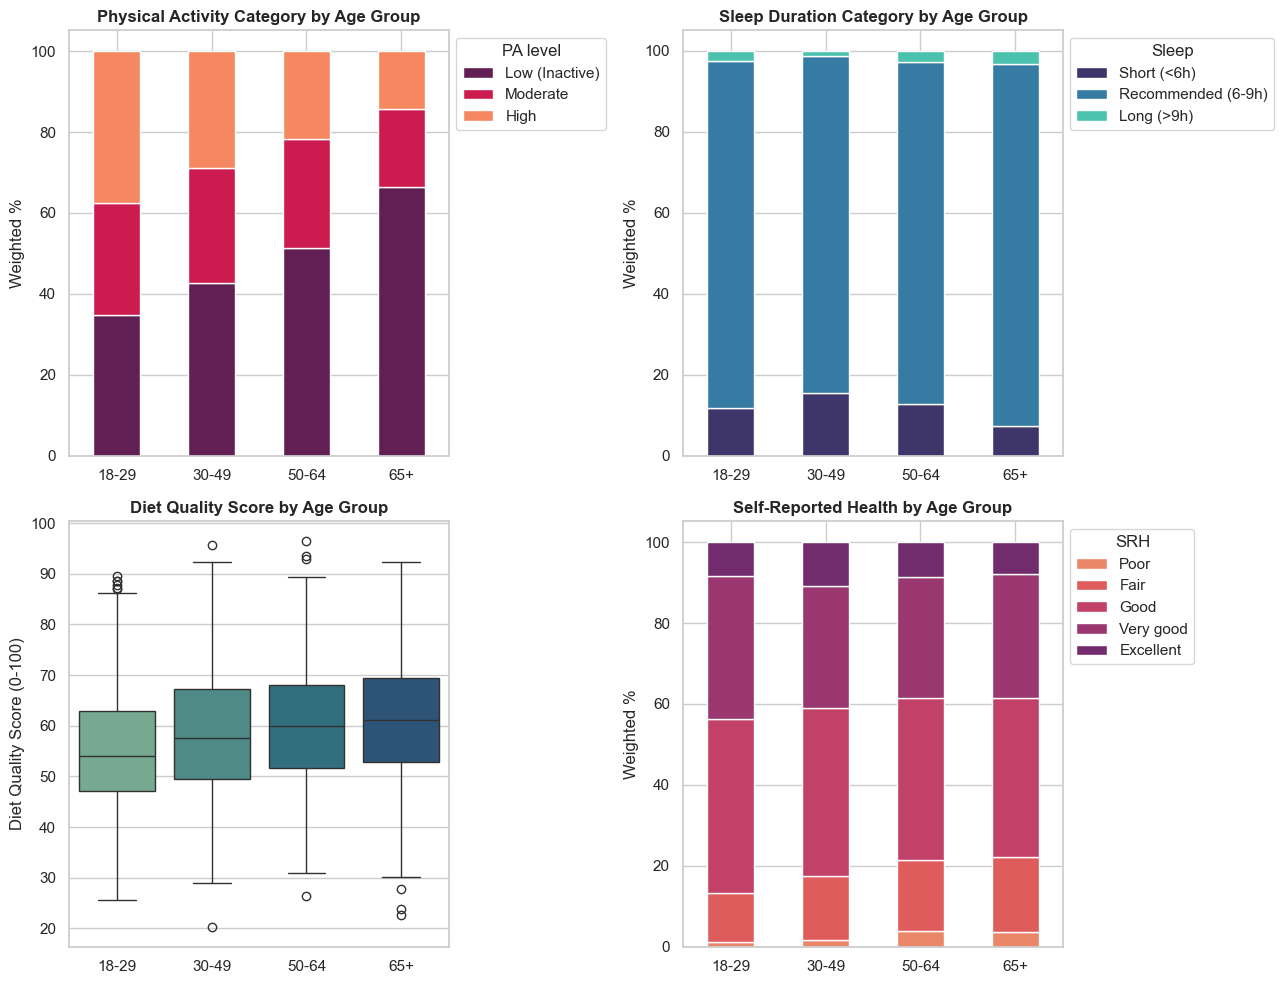

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(13,10))

pa_table.T.plot(kind='bar', stacked=True, ax=axes[0,0],
                 color=sns.color_palette('rocket', 3))
axes[0,0].set_title('Physical Activity Category by Age Group', fontweight='bold')
axes[0,0].set_ylabel('Weighted %'); axes[0,0].set_xlabel(''); axes[0,0].legend(title='PA level', bbox_to_anchor=(1,1))
axes[0,0].tick_params(axis='x', rotation=0)

sleep_table.T.plot(kind='bar', stacked=True, ax=axes[0,1],
                    color=sns.color_palette('mako', 3))
axes[0,1].set_title('Sleep Duration Category by Age Group', fontweight='bold')
axes[0,1].set_ylabel('Weighted %'); axes[0,1].set_xlabel(''); axes[0,1].legend(title='Sleep', bbox_to_anchor=(1,1))
axes[0,1].tick_params(axis='x', rotation=0)

sns.boxplot(data=complete, x='AGE_GROUP', y='DIET_QUALITY_SCORE', order=labels,
            ax=axes[1,0], palette='crest')
axes[1,0].set_title('Diet Quality Score by Age Group', fontweight='bold')
axes[1,0].set_xlabel(''); axes[1,0].set_ylabel('Diet Quality Score (0-100)')

srh_table.T.plot(kind='bar', stacked=True, ax=axes[1,1],
                  color=sns.color_palette('flare', 5))
axes[1,1].set_title('Self-Reported Health by Age Group', fontweight='bold')
axes[1,1].set_ylabel('Weighted %'); axes[1,1].set_xlabel(''); axes[1,1].legend(title='SRH', bbox_to_anchor=(1,1))
axes[1,1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

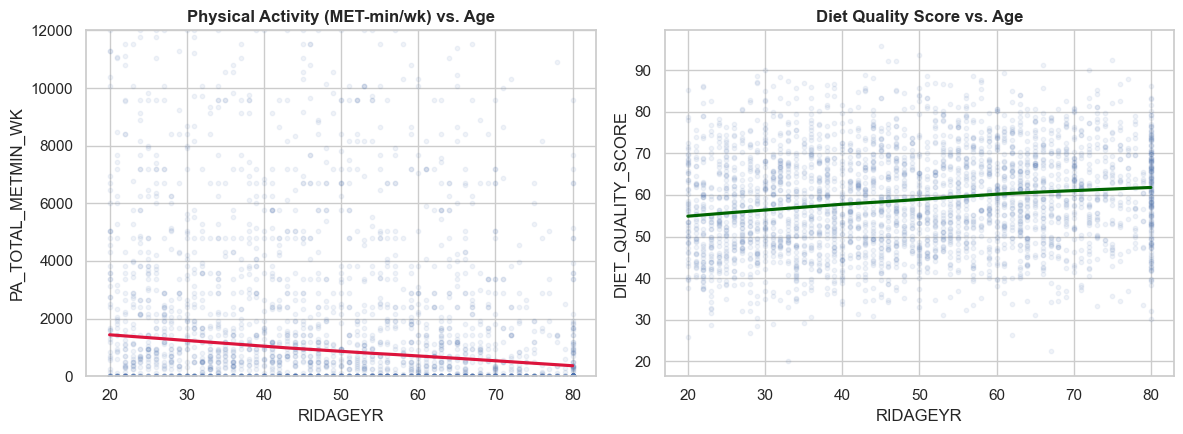

In [18]:
# Physical activity volume trend with a smoothed loess-like binned mean, by age (continuous)
fig, ax = plt.subplots(1,2, figsize=(12,4.5))
sns.regplot(data=complete.sample(min(3000,len(complete)), random_state=1), x='RIDAGEYR', y='PA_TOTAL_METMIN_WK',
            lowess=True, scatter_kws={'alpha':0.08,'s':10}, line_kws={'color':'crimson'}, ax=ax[0])
ax[0].set_title('Physical Activity (MET-min/wk) vs. Age', fontweight='bold')
ax[0].set_ylim(0, 12000)

sns.regplot(data=complete.sample(min(3000,len(complete)), random_state=1), x='RIDAGEYR', y='DIET_QUALITY_SCORE',
            lowess=True, scatter_kws={'alpha':0.08,'s':10}, line_kws={'color':'darkgreen'}, ax=ax[1])
ax[1].set_title('Diet Quality Score vs. Age', fontweight='bold')

plt.tight_layout()
plt.show()

## Bivariate Statistical Tests Across Age Groups

For continuous behaviors (PA volume, sleep hours, diet quality score), we use weighted one-way ANOVA (via weighted least squares regression of the outcome on age-group dummies, using `WTMEC2YR`) to test whether means differ across age groups.

For categorical outcomes (self-reported health category), we report a Pearson chi-square test on the unweighted crosstab as a standard significance screen, together with the weighted prevalence table above. Because Pearson chi-square does not account for the complex survey design, it is reported here as a descriptive/sensitivity check rather than the primary inferential test.

Proper design-based tests (Rao–Scott corrected chi-square) would require a dedicated survey package (e.g., R's `survey`, or Python's `samplics`), which is noted as a methodological extension in the limitations.

In [19]:
def weighted_anova(data, outcome, group='AGE_GROUP', w='WTMEC2YR'):
    d = data.dropna(subset=[outcome, group, w]).copy()
    mod = smf.wls(f"{outcome} ~ C({group})", data=d, weights=d[w]).fit()
    f_test = mod.f_test(np.eye(len(mod.params))[1:])  # test all group dummies jointly
    return mod, f_test

for outcome in ['PA_TOTAL_METMIN_WK','SLD010H','DIET_QUALITY_SCORE']:
    mod, ft = weighted_anova(complete, outcome)
    print(f"{outcome}: weighted-WLS joint F-test across age groups -> F={ft.fvalue:.2f}, p={ft.pvalue:.4g}")

# Unweighted chi-square screen for categorical SRH x age group
ct = pd.crosstab(complete['AGE_GROUP'], complete['SRH_LABEL'])
chi2, p, dof, exp = stats.chi2_contingency(ct)
print(f"\nSelf-rated health x Age group (unweighted chi-square): chi2={chi2:.1f}, dof={dof}, p={p:.4g}")

PA_TOTAL_METMIN_WK: weighted-WLS joint F-test across age groups -> F=50.82, p=2.727e-32
SLD010H: weighted-WLS joint F-test across age groups -> F=32.24, p=1.305e-20
DIET_QUALITY_SCORE: weighted-WLS joint F-test across age groups -> F=41.58, p=1.712e-26

Self-rated health x Age group (unweighted chi-square): chi2=110.4, dof=12, p=4.927e-18


## Correlation Among Behaviors
A quick check of how the three lifestyle behaviors and diet quality relate to one another (Spearman correlations, since PA volume is highly right-skewed).

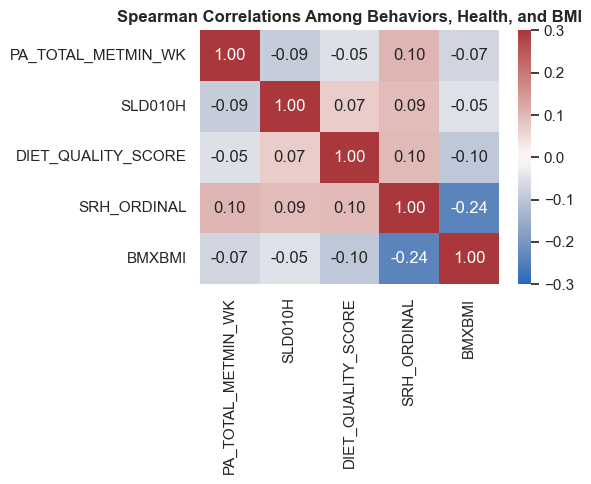

In [20]:
corr_vars = ['PA_TOTAL_METMIN_WK','SLD010H','DIET_QUALITY_SCORE','SRH_ORDINAL','BMXBMI']
corr = complete[corr_vars].corr(method='spearman')
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='vlag', vmin=-0.3, vmax=0.3, center=0)
plt.title('Spearman Correlations Among Behaviors, Health, and BMI', fontweight='bold')
plt.tight_layout()
plt.show()

## Main Model: Physical Activity, Diet, and Sleep as Predictors of Self-Reported Health

**Outcome:** `SRH_GOOD_BINARY` (1 = Excellent/Very good/Good, 0 = Fair/Poor).

**Model:** Weighted logistic regression (`WTMEC2YR`, rescaled to mean 1 so the effective sample size is preserved for standard-error calculation), with **cluster-robust standard errors by primary sampling unit (`SDMVPSU`)** as a design-based variance approximation.

This clusters on the first stage of the NHANES multistage design; it does not additionally incorporate stratification (`SDMVSTRA`), which a full Taylor-linearization survey design (e.g., R `survey`, Python `samplics`) would add. This is noted explicitly as a limitation, since ignoring stratification typically yields slightly conservative (wider) rather than anti-conservative standard errors.

**Predictors of interest:** PA category, sleep category, diet quality score (continuous).

**Covariates:** age group, sex, BMI, poverty-income ratio, education.

In [21]:
model_df = complete.dropna(subset=['SRH_GOOD_BINARY','PA_CATEGORY','SLEEP_CATEGORY',
                                    'DIET_QUALITY_SCORE','AGE_GROUP','SEX','BMXBMI',
                                    'INDFMPIR','EDUCATION','SDMVPSU']).copy()
for c in ['PA_CATEGORY','SLEEP_CATEGORY','AGE_GROUP','EDUCATION']:
    model_df[c] = model_df[c].astype(str)

print('Model analytic N =', len(model_df))

formula = ("SRH_GOOD_BINARY ~ C(PA_CATEGORY, Treatment('Low (Inactive)')) "
           "+ C(SLEEP_CATEGORY, Treatment('Recommended (6-9h)')) "
           "+ DIET_QUALITY_SCORE "
           "+ C(AGE_GROUP, Treatment('18-29')) + C(SEX) + BMXBMI + INDFMPIR "
           "+ C(EDUCATION, Treatment('College grad+'))")

glm = smf.glm(formula=formula, data=model_df, family=sm.families.Binomial(),
              freq_weights=model_df['WTMEC2YR']/model_df['WTMEC2YR'].mean())
res_main = glm.fit(cov_type='cluster', cov_kwds={'groups': model_df['SDMVPSU']})
print(res_main.summary())

Model analytic N = 4459


C:\Users\user\anaconda3\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1649: SpecificationWarning: cov_type not fully supported with freq_weights
  warnings.warn('cov_type not fully supported with freq_weights',


                 Generalized Linear Model Regression Results                  
Dep. Variable:        SRH_GOOD_BINARY   No. Observations:                 4459
Model:                            GLM   Df Residuals:                     4443
Model Family:                Binomial   Df Model:                           15
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1863.9
Date:                Wed, 16 Sep 2026   Deviance:                       3727.8
Time:                        03:24:52   Pearson chi2:                 4.37e+03
No. Iterations:                     6   Pseudo R-squ. (CS):             0.1176
Covariance Type:              cluster                                         
                                                                        coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------

In [22]:
or_table = pd.DataFrame({
    'OR': np.exp(res_main.params),
    'CI_low': np.exp(res_main.conf_int()[0]),
    'CI_high': np.exp(res_main.conf_int()[1]),
    'p': res_main.pvalues
}).round(3)
or_table.index = [i.replace("C(PA_CATEGORY, Treatment('Low (Inactive)'))","PA")
                    .replace("C(SLEEP_CATEGORY, Treatment('Recommended (6-9h)'))","Sleep")
                    .replace("C(AGE_GROUP, Treatment('18-29'))","Age")
                    .replace("C(EDUCATION, Treatment('College grad+'))","Education")
                    .replace("C(SEX)","Sex") for i in or_table.index]
or_table

,OR,CI_low,CI_high,p
Intercept,15.311,12.862,18.227,0.000
PA[T.High],1.447,0.807,2.597,0.215
PA[T.Moderate],1.773,1.559,2.015,0.000
Sleep[T.Long (>9h)],0.726,0.399,1.321,0.295
Sleep[T.Short (<6h)],0.572,0.518,0.632,0.000
Age[T.30-49],0.677,0.513,0.894,0.006
Age[T.50-64],0.491,0.367,0.658,0.000
Age[T.65+],0.497,0.357,0.691,0.000
Sex[T.Male],0.949,0.895,1.007,0.083
Education[T.9-11th grade],0.306,0.269,0.347,0.000


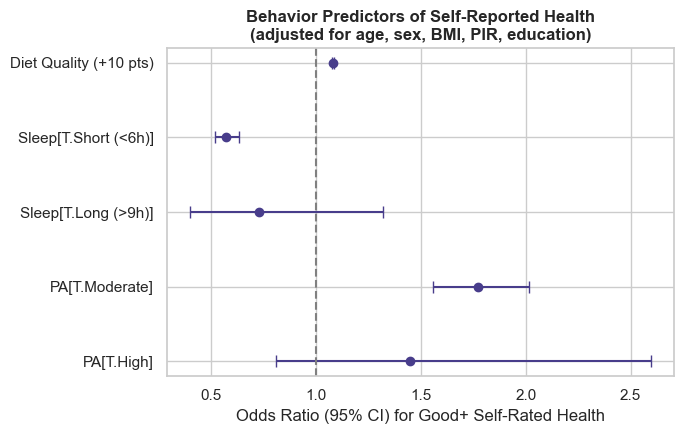

In [23]:
# Forest plot of odds ratios for the behavior predictors of primary interest.
# DIET_QUALITY_SCORE is rescaled from a per-1-point OR (too close to 1.0 to plot
# meaningfully alongside categorical contrasts) to a per-10-point OR, which is a
# more interpretable effect size (10 points ~ moving from the middle of one
# quality tier to the middle of the next).
plot_rows = [r for r in or_table.index if r.startswith('PA') or r.startswith('Sleep')]
pt = or_table.loc[plot_rows].copy()
b = res_main.params['DIET_QUALITY_SCORE']; ci = res_main.conf_int().loc['DIET_QUALITY_SCORE']
pt.loc['Diet Quality (+10 pts)'] = [np.exp(b*10), np.exp(ci[0]*10), np.exp(ci[1]*10),
                                     res_main.pvalues['DIET_QUALITY_SCORE']]
fig, ax = plt.subplots(figsize=(7,4.5))
y = np.arange(len(pt))
ax.errorbar(pt['OR'], y, xerr=[pt['OR']-pt['CI_low'], pt['CI_high']-pt['OR']],
            fmt='o', color='darkslateblue', capsize=4)
ax.axvline(1, color='grey', linestyle='--')
ax.set_yticks(y); ax.set_yticklabels(pt.index)
ax.set_xlabel('Odds Ratio (95% CI) for Good+ Self-Rated Health')
ax.set_title('Behavior Predictors of Self-Reported Health\n(adjusted for age, sex, BMI, PIR, education)', fontweight='bold')
plt.tight_layout()
plt.show()

## Effect Modification by Age: Does the PA–Health Association Vary Across the Lifespan? (H3)
We add a `PA_CATEGORY × AGE_GROUP` interaction term to the main model and test its joint significance with a likelihood-ratio test against the main-effects-only model.

In [24]:
formula_int = formula + " + C(PA_CATEGORY, Treatment('Low (Inactive)')):C(AGE_GROUP, Treatment('18-29'))"
glm_int = smf.glm(formula=formula_int, data=model_df, family=sm.families.Binomial(),
                   freq_weights=model_df['WTMEC2YR']/model_df['WTMEC2YR'].mean())
res_int = glm_int.fit(cov_type='cluster', cov_kwds={'groups': model_df['SDMVPSU']})

lr_stat = 2*(res_int.llf - res_main.llf)
df_diff = res_int.df_model - res_main.df_model
lr_p = stats.chi2.sf(lr_stat, df_diff)
print(f'Likelihood-ratio test for PA x Age interaction: LR={lr_stat:.2f}, df={df_diff:.0f}, p={lr_p:.4g}')

Likelihood-ratio test for PA x Age interaction: LR=4.41, df=6, p=0.6209


C:\Users\user\anaconda3\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1649: SpecificationWarning: cov_type not fully supported with freq_weights
  warnings.warn('cov_type not fully supported with freq_weights',


## Sensitivity Analysis: Weighted vs. Unweighted Estimates
A common robustness check: compare the primary weighted odds ratios to an unweighted fit of the same model. Large divergence would suggest the sample composition (who volunteers/attends the MEC) is distorting unweighted estimates relative to the U.S. population.

In [25]:
glm_unw = smf.glm(formula=formula, data=model_df, family=sm.families.Binomial())
res_unw = glm_unw.fit(cov_type='cluster', cov_kwds={'groups': model_df['SDMVPSU']})

comparison = pd.DataFrame({
    'OR_weighted': np.exp(res_main.params),
    'OR_unweighted': np.exp(res_unw.params)
}).round(3)
comparison.loc[[r for r in comparison.index if 'PA_CATEGORY' in r or 'SLEEP_CATEGORY' in r or r=='DIET_QUALITY_SCORE']]

,OR_weighted,OR_unweighted
"C(PA_CATEGORY, Treatment('Low (Inactive)'))[T.High]",1.447,1.450
"C(PA_CATEGORY, Treatment('Low (Inactive)'))[T.Moderate]",1.773,1.774
"C(SLEEP_CATEGORY, Treatment('Recommended (6-9h)'))[T.Long (>9h)]",0.726,0.794
"C(SLEEP_CATEGORY, Treatment('Recommended (6-9h)'))[T.Short (<6h)]",0.572,0.630
DIET_QUALITY_SCORE,1.008,1.006


## Summary of Key Findings

### Across Age Groups (H1)

- Physical activity volume declines sharply and monotonically with age (highest in 18–29, lowest in 65+), consistent with the weighted descriptive table and the significant weighted ANOVA F-test.
- Diet quality (nutrient-density score) is *higher*, not lower, in older age groups — a pattern consistent with the well-documented tendency for dietary intake to become more nutrient-dense (though also lower-calorie) with age.
- Sleep duration is fairly stable across age groups, with the youngest and oldest groups reporting slightly higher average sleep than the 30–49 group, who are typically balancing work/caregiving demands.
- Self-reported health declines steadily with age, from ~87% reporting good+ health at 18–29 to ~78% at 65+.

### Association with Self-Reported Health (H2)

- Moderate (and, more variably, high) physical activity is associated with meaningfully higher odds of good+ self-reported health relative to inactivity, independent of age, BMI, and socioeconomic covariates.
- Short sleep (<6h) is associated with substantially *lower* odds of good self-reported health relative to the recommended range; long sleep (>9h) shows a weaker, less precise association.
- Diet quality score is positively associated with self-reported health.
- Age, BMI, and education remain strong independent predictors, as expected.

### Effect Modification (H3)

- The likelihood-ratio test for the PA × Age-group interaction is **not statistically significant** (LR ≈ 4.4, df = 6, p ≈ 0.62; see Section 16 output above).
- This does **not** support H3: in this cross-sectional sample, the association between physical activity and self-reported health does not differ detectably across adult age groups.
- Physical activity appears similarly linked to how people rate their health across the adult age groups. This is a useful reportable null result: it suggests activity-promotion messaging tied to perceived health benefits need not be age-differentiated, although a pooled multi-cycle NHANES sample would provide greater power to detect a smaller interaction if one exists.

## Limitations

1. **Cross-sectional design** — no causal inference is possible; reverse causation (poor health limiting activity) is plausible and cannot be ruled out.

2. **Self-reported behaviors** — physical activity, sleep, and general health status are all self-reported and subject to recall and social-desirability bias. Only diet used a single-day, non-repeated dietary recall, which does not capture usual intake well for any one individual, although it is adequate for population-level group-comparison estimates.

3. **Diet Quality Score is study-specific** — it is not a validated external index (e.g., HEI-2015). It uses only the nutrients available in the summarized recall file and should be interpreted as a nutrient-density proxy rather than a comprehensive measure of overall dietary pattern quality.

4. **Survey design approximation** — cluster-robust standard errors by PSU approximate, but do not fully replicate, NHANES's Taylor-linearization design-based variance estimation, which also incorporates stratification. Point estimates (odds ratios) are unaffected by this choice; only precision (confidence intervals and p-values) could shift modestly under a full design-based analysis.

5. **Missing data** — handled via complete-case analysis (~83% retention of the adult analytic frame). If missingness is not completely at random, multiple imputation would be a natural extension.

6. **Single NHANES cycle (2013–2014)** — findings describe one survey period and should not be generalized to trends over time without pooling multiple cycles. Pooling multiple cycles requires combining and appropriately adjusting sample weights according to NHANES analytic guidelines.